In [2]:
""" Script to organise and downsampling the images from the dataset.

During resizing, the smaller edge of the image will be matched to this number.
"""
from pathlib import Path
from torchvision.transforms import Resize
from torchvision.datasets.folder import default_loader
import zipfile


source_dir = Path('/sourcedata/')
raw_dir = Path('/rawdata/')

resize_fn = Resize(512)

for image_file in source_dir.glob('**/*.jpg'):
    image = default_loader(image_file)
    new_image = resize_fn(image)

    new_dir = raw_dir / image_file.relative_to("/sourcedata/").parent
    new_dir.mkdir(parents=True, exist_ok=True)
    new_image.save(new_dir / image_file.name)

# Unzip medical reports into raw_dir
with zipfile.ZipFile(source_dir / "mimic-cxr-reports.zip", 'r') as zip_ref:
    zip_ref.extractall(raw_dir)



In [ ]:
""" Script to organise and downsampling the images from the dataset.

During resizing, the smaller edge of the image will be matched to this number.
"""
from pathlib import Path
from torchvision.transforms import Resize
from torchvision.datasets.folder import default_loader
import zipfile
import argparse
import sys




source_dir = Path("/home/vito/ibrahimm/projects/AI4Health/sourcedata/Chest Xray/physionet.org/files/mimic-cxr-jpg/2.0.0/")
raw_dir = Path("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data")
resize_size = 512


# Check if source directory exists
if not source_dir.exists():
    print(f"Error: Source directory {source_dir} does not exist!")
    sys.exit(1)

print(f"Processing images from: {source_dir}")
print(f"Output directory: {raw_dir}")
print(f"Resize size: {resize_size}")

# Create output directory if it doesn't exist
raw_dir.mkdir(parents=True, exist_ok=True)

resize_fn = Resize(resize_size)

# Count total files for progress tracking
jpg_files = list(source_dir.glob('files/**/*.jpg'))
total_files = len(jpg_files)
print(f"Found {total_files} JPG files to process")




Processing images from: /home/vito/ibrahimm/projects/AI4Health/sourcedata/Chest Xray/physionet.org/files/mimic-cxr-jpg/2.0.0/files
Output directory: /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data
Resize size: 512
Found 377112 JPG files to process


In [ ]:

processed_count = 0
for image_file in jpg_files:
    try:
        image = default_loader(image_file)
        new_image = resize_fn(image)
        
        # Create relative path structure
        relative_path = image_file.relative_to(source_dir)
        new_dir = raw_dir / relative_path.parent
        new_dir.mkdir(parents=True, exist_ok=True)
        
        new_image.save(new_dir / image_file.name)
        processed_count += 1
        
        if processed_count % 1000 == 0:
            print(f"Processed {processed_count}/{total_files} images")
            
    except Exception as e:
        print(f"Error processing {image_file}: {e}")
        continue

print(f"Successfully processed {processed_count}/{total_files} images")



In [6]:
# Check for and extract medical reports zip file
reports_zip = source_dir / "mimic-cxr-2.0.0-chexpert.csv.gz"
if reports_zip.exists():
    print(f"Extracting medical reports from {reports_zip}")
    try:
        with zipfile.ZipFile(reports_zip, 'r') as zip_ref:
            zip_ref.extractall(raw_dir)
        print("Medical reports extracted successfully")
    except Exception as e:
        print(f"Error extracting reports: {e}")
else:
    print("No mimic-cxr-reports.zip found in source directory")

No mimic-cxr-reports.zip found in source directory


In [7]:
reports_zip

PosixPath('/home/vito/ibrahimm/projects/AI4Health/sourcedata/Chest Xray/physionet.org/files/mimic-cxr-jpg/2.0.0/files/mimic-cxr-2.0.0-chexpert.csv.gz')

# efficient

In [114]:
""" Script to organise and downsampling the images from the dataset.

During resizing, the smaller edge of the image will be matched to this number.
Uses parallel processing for faster execution on large datasets.
"""
from pathlib import Path
from torchvision.transforms import Resize
from torchvision.datasets.folder import default_loader
import zipfile
import argparse
import sys
import multiprocessing as mp
from functools import partial
import time
from tqdm import tqdm
import os


def process_single_image(image_file, source_dir, raw_dir, resize_size):
    """Process a single image file."""
    
    try:
        # Load and resize image
        image = default_loader(image_file)
        resize_fn = Resize(resize_size)
        new_image = resize_fn(image)
        
        # Create output directory structure
        relative_path = image_file.relative_to(source_dir)
        new_dir = raw_dir / relative_path.parent
        new_dir.mkdir(parents=True, exist_ok=True)
        
        # Save resized image
        output_path = new_dir / image_file.name
        new_image.save(output_path)
        
        return True, str(image_file)
    except Exception as e:
        return False, f"Error processing {image_file}: {e}"

source_dir = Path("/home/vito/ibrahimm/projects/AI4Health/sourcedata/Chest Xray/physionet.org/files/mimic-cxr-jpg/2.0.0/")
raw_dir = Path("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data")
resize_size = 512
num_workers = None
batch_size = 1000   
# Check if source directory exists
if not source_dir.exists():
    print(f"Error: Source directory {source_dir} does not exist!")
    sys.exit(1)

# Set number of workers
if num_workers is None:
    num_workers = mp.cpu_count()

print(f"Processing images from: {source_dir}")
print(f"Output directory: {raw_dir}")
print(f"Resize size: {resize_size}")
print(f"Using {num_workers} parallel workers")
print(f"Batch size: {batch_size}")

# Create output directory if it doesn't exist
raw_dir.mkdir(parents=True, exist_ok=True)

# Find all JPG files
print("Scanning for JPG files...")
jpg_files = list(source_dir.glob('**/*.jpg'))
total_files = len(jpg_files)
print(f"Found {total_files} JPG files to process")

if total_files == 0:
    print("No JPG files found in source directory!")
    




Processing images from: /home/vito/ibrahimm/projects/AI4Health/sourcedata/Chest Xray/physionet.org/files/mimic-cxr-jpg/2.0.0
Output directory: /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data
Resize size: 512
Using 256 parallel workers
Batch size: 1000
Scanning for JPG files...
Found 377112 JPG files to process


In [115]:

# Process images in parallel
start_time = time.time()
successful_count = 0
error_count = 0

# Create partial function with fixed arguments
process_func = partial(process_single_image, 
                        source_dir=source_dir, 
                        raw_dir=raw_dir, 
                        resize_size=resize_size)

# Process in batches to avoid memory issues
for i in range(0, total_files, batch_size):
    batch_files = jpg_files[i:i + batch_size]
    batch_num = i // batch_size + 1
    total_batches = (total_files + batch_size - 1) // batch_size
    
    print(f"\nProcessing batch {batch_num}/{total_batches} ({len(batch_files)} images)")
    
    # Use multiprocessing pool
    with mp.Pool(processes=num_workers) as pool:
        # Use tqdm for progress bar
        results = list(tqdm(
            pool.imap(process_func, batch_files),
            total=len(batch_files),
            desc=f"Batch {batch_num}/{total_batches}"
        ))
    
    # Count results
    for success, message in results:
        if success:
            successful_count += 1
        else:
            error_count += 1
            print(f"  {message}")

end_time = time.time()
processing_time = end_time - start_time

print(f"\n{'='*50}")
print(f"Processing complete!")
print(f"Total time: {processing_time:.2f} seconds ({processing_time/60:.2f} minutes)")
print(f"Successfully processed: {successful_count}/{total_files} images")
print(f"Errors: {error_count}")
print(f"Average time per image: {processing_time/total_files:.3f} seconds")
print(f"Images per second: {total_files/processing_time:.1f}")



Processing batch 1/378 (1000 images)


Batch 1/378: 100%|██████████| 1000/1000 [00:45<00:00, 21.98it/s]



Processing batch 2/378 (1000 images)


Batch 2/378: 100%|██████████| 1000/1000 [00:43<00:00, 23.11it/s]



Processing batch 3/378 (1000 images)


Batch 3/378:  15%|█▌        | 150/1000 [00:50<04:47,  2.95it/s]


KeyboardInterrupt: 

In [19]:
def extract_gz_file(source_path, dest_path):
    """Extract a gzipped file to the specified destination path.
    
    Args:
        source_path (Path): Path to the source .gz file
        dest_path (Path): Path where the extracted file should be saved
        
    Returns:
        bool: True if extraction was successful, False otherwise
    """
    if not source_path.exists():
        print(f"\nSource file {source_path} not found")
        return False
        
    print(f"\nExtracting {source_path.name} to {dest_path}")
    try:
        import gzip
        import shutil
        with gzip.open(source_path, 'rb') as f_in:
            with open(dest_path, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print("File extracted successfully")
        return True
    except Exception as e:
        print(f"Error extracting file: {e}")
        return False

def extract_zip_file(source_path, dest_path):
    """Extract a ZIP file to the specified destination path.
    
    Args:
        source_path (Path): Path to the source .zip file
        dest_path (Path): Path where the extracted files should be saved
        
    Returns:
        bool: True if extraction was successful, False otherwise
    """
    if not source_path.exists():
        print(f"\nSource file {source_path} not found")
        return False
        
    print(f"\nExtracting {source_path.name} to {dest_path}")
    try:
        import zipfile
        with zipfile.ZipFile(source_path, 'r') as zip_ref:
            zip_ref.extractall(dest_path)
        print("Files extracted successfully")
        return True
    except Exception as e:
        print(f"Error extracting file: {e}")
        return False


In [17]:
# Extract the medical reports file

reports_source = source_dir / "mimic-cxr-reports.tar.gz"
reports_dest = raw_dir / "mimic-cxr-reports"
extract_gz_file(reports_source, reports_dest)





Source file /mnthpc/netapp01/projects/AI4Health/sourcedata/Chest Xray/physionet.org/files/mimic-cxr/2.0.0/mimic-cxr-reports.tar.gz not found


False

In [20]:
# Extract the medical reports file
source_dir_mimic = Path("/mnthpc/netapp01/projects/AI4Health/sourcedata/Chest Xray/physionet.org/files/mimic-cxr/2.0.0/")
reports_source = source_dir_mimic / "mimic-cxr-reports.zip"
reports_dest = raw_dir / "mimic-cxr-reports"
extract_zip_file(reports_source, reports_dest)





Extracting mimic-cxr-reports.zip to /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data/mimic-cxr-reports
Files extracted successfully


True

In [8]:
from pathlib import Path
raw_dir = Path("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data")
subjects = pd.read_csv(raw_dir / "mimic-cxr-2.0.0-metadata.csv")


In [9]:
subjects['ViewPosition'].value_counts()

ViewPosition
AP                147173
PA                 96161
LATERAL            82853
LL                 35133
PA LLD                 4
LAO                    3
RAO                    3
AP AXIAL               2
AP LLD                 2
XTABLE LATERAL         2
AP RLD                 2
SWIMMERS               1
PA RLD                 1
LPO                    1
Name: count, dtype: int64

# Mimic IV

In [2]:
import pandas as pd
patients = pd.read_csv("/mnthpc/netapp01/projects/AI4Health/sourcedata/MIMIC-IV/physionet.org/files/mimiciv/1.0/core/patients.csv")
admissions = pd.read_csv("/mnthpc/netapp01/projects/AI4Health/sourcedata/MIMIC-IV/physionet.org/files/mimiciv/1.0/core/admissions.csv")

In [3]:
merged_metadata_mimiciv = pd.merge(patients, admissions, on="subject_id")[['subject_id', 'gender', 'anchor_age', 
       'ethnicity']].drop_duplicates(subset=['subject_id'])


In [66]:
# Group by subject_id and handle insurance conflicts
def resolve_insurance_conflicts(group):
    if len(group) == 1:
        return group
    
    # Get unique insurance values for this subject
    unique_insurance = group['insurance'].unique()
    
    # If there's only one insurance type, return as is
    if len(unique_insurance) == 1:
        return group
    
    # If there are multiple insurance types and 'Other' is one of them
    if 'Other' in unique_insurance:
        # Filter out 'Other' and keep the other insurance type
        non_other_insurance = [ins for ins in unique_insurance if ins != 'Other']
        if non_other_insurance:
            # Keep only records with non-'Other' insurance
            return group[group['insurance'].isin(non_other_insurance)]
    
    # If no conflicts or no 'Other' involved, return as is
    return group

# Apply the resolution function to each subject group
merged_metadata_mimiciv_resolved = merged_metadata_mimiciv.groupby('subject_id').apply(resolve_insurance_conflicts).reset_index(drop=True)

merged_metadata_mimiciv_resolved

/tmp/ipykernel_3480759/753513276.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_metadata_mimiciv_resolved = merged_metadata_mimiciv.groupby('subject_id').apply(resolve_insurance_conflicts).reset_index(drop=True)


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,insurance,ethnicity
0,10000019,M,0,2129,2008 - 2010,NaN,Other,WHITE
1,10000032,F,52,2180,2014 - 2016,NaN,Medicaid,WHITE
2,10000032,F,52,2180,2014 - 2016,NaN,Medicaid,WHITE
3,10000032,F,52,2180,2014 - 2016,NaN,Medicaid,WHITE
4,10000044,F,0,2150,2017 - 2019,NaN,Other,ASIAN
...,...,...,...,...,...,...,...,...
483982,19999828,F,46,2147,2017 - 2019,NaN,Other,WHITE
483983,19999828,F,46,2147,2017 - 2019,NaN,Other,WHITE
483984,19999840,M,58,2164,2008 - 2010,2164-09-17,Other,WHITE
483985,19999840,M,58,2164,2008 - 2010,2164-09-17,Other,WHITE


In [79]:
subject_counts.sort_values(ascending=False)

subject_id
15496609    238
15464144    185
10714009    163
16662316    142
15229574    130
           ... 
19997843      1
19997886      1
19997922      1
19997928      1
19997471      1
Length: 256878, dtype: int64

In [80]:
merged_metadata_mimiciv['insurance'].unique()

array(['Other', 'Medicaid', 'Medicare'], dtype=object)

In [69]:
merged_metadata_mimiciv_resolved[merged_metadata_mimiciv_resolved['subject_id'] == 15496609        ]

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,insurance,ethnicity
266057,15496609,M,57,2154,2008 - 2010,NaN,Medicaid,BLACK/AFRICAN AMERICAN
266058,15496609,M,57,2154,2008 - 2010,NaN,Medicaid,BLACK/AFRICAN AMERICAN
266059,15496609,M,57,2154,2008 - 2010,NaN,Medicaid,BLACK/AFRICAN AMERICAN
266060,15496609,M,57,2154,2008 - 2010,NaN,Medicaid,BLACK/AFRICAN AMERICAN
266061,15496609,M,57,2154,2008 - 2010,NaN,Medicaid,BLACK/AFRICAN AMERICAN
...,...,...,...,...,...,...,...,...
266205,15496609,M,57,2154,2008 - 2010,NaN,Medicare,BLACK/AFRICAN AMERICAN
266206,15496609,M,57,2154,2008 - 2010,NaN,Medicaid,BLACK/AFRICAN AMERICAN
266207,15496609,M,57,2154,2008 - 2010,NaN,Medicaid,BLACK/AFRICAN AMERICAN
266208,15496609,M,57,2154,2008 - 2010,NaN,Medicaid,BLACK/AFRICAN AMERICAN


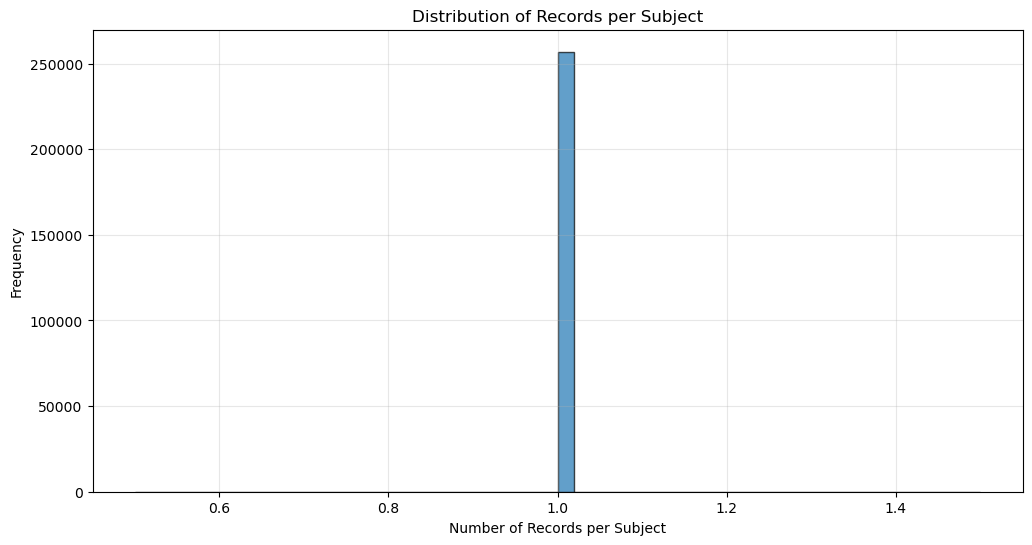

Summary statistics of records per subject:
Mean: 1.00
Median: 1.00
Min: 1
Max: 1
Total subjects: 256878


In [93]:
import matplotlib.pyplot as plt

# Count records per subject and create a histogram
subject_counts = merged_metadata_mimiciv.groupby('subject_id').size()
plt.figure(figsize=(12, 6))
plt.hist(subject_counts.values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Records per Subject')
plt.ylabel('Frequency')
plt.title('Distribution of Records per Subject')
plt.grid(True, alpha=0.3)
plt.show()

# Print summary statistics
print(f"Summary statistics of records per subject:")
print(f"Mean: {subject_counts.mean():.2f}")
print(f"Median: {subject_counts.median():.2f}")
print(f"Min: {subject_counts.min()}")
print(f"Max: {subject_counts.max()}")
print(f"Total subjects: {len(subject_counts)}")

In [109]:
subjects_with_metadata = pd.merge(subjects,merged_metadata_mimiciv, on="subject_id", how="left")
subjects_with_metadata

,dicom_id,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning,gender,anchor_age,ethnicity
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,CHEST (PA AND LAT),PA,3056,2544,21800506,213014.531,CHEST (PA AND LAT),postero-anterior,Erect,F,52.0,WHITE
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,CHEST (PA AND LAT),LATERAL,3056,2544,21800506,213014.531,CHEST (PA AND LAT),lateral,Erect,F,52.0,WHITE
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,CHEST (PA AND LAT),PA,3056,2544,21800626,165500.312,CHEST (PA AND LAT),postero-anterior,Erect,F,52.0,WHITE
3,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,10000032,53189527,CHEST (PA AND LAT),LATERAL,3056,2544,21800626,165500.312,CHEST (PA AND LAT),lateral,Erect,F,52.0,WHITE
4,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,10000032,53911762,CHEST (PORTABLE AP),AP,2705,2539,21800723,80556.875,CHEST (PORTABLE AP),antero-posterior,NaN,F,52.0,WHITE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377105,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,19999733,57132437,CHEST (PA AND LAT),PA,3056,2544,21520708,224550.171,CHEST (PA AND LAT),postero-anterior,Erect,F,19.0,WHITE
377106,58c403aa-35ff8bd9-73e39f54-8dc9cc5d-e0ec3fa9,19999733,57132437,CHEST (PA AND LAT),LATERAL,3056,2544,21520708,224550.171,CHEST (PA AND LAT),lateral,Erect,F,19.0,WHITE
377107,58766883-376a15ce-3b323a28-6af950a0-16b793bd,19999987,55368167,CHEST (PORTABLE AP),AP,2544,3056,21451104,51448.218,CHEST (PORTABLE AP),antero-posterior,Erect,F,57.0,UNKNOWN
377108,7ba273af-3d290f8d-e28d0ab4-484b7a86-7fc12b08,19999987,58621812,CHEST (PORTABLE AP),AP,3056,2544,21451102,202809.234,CHEST (PORTABLE AP),antero-posterior,Erect,F,57.0,UNKNOWN


In [110]:
subjects_with_metadata.to_csv(raw_dir / "mimic-cxr-2.0.0-metadata-with-demographics.csv", index=False)

In [ ]:
import pandas as pd
subjects_with_metadata = pd.read_csv(raw_dir / "mimic-cxr-2.0.0-metadata-with-demographics.csv")